In [1]:
import numpy as py
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('/content/Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [3]:
df.shape

(545, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [5]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


In [6]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='object')

In [7]:
df.isnull().sum()

,0
price,0
area,0
bedrooms,0
bathrooms,0
stories,0
mainroad,0
guestroom,0
basement,0
hotwaterheating,0
airconditioning,0


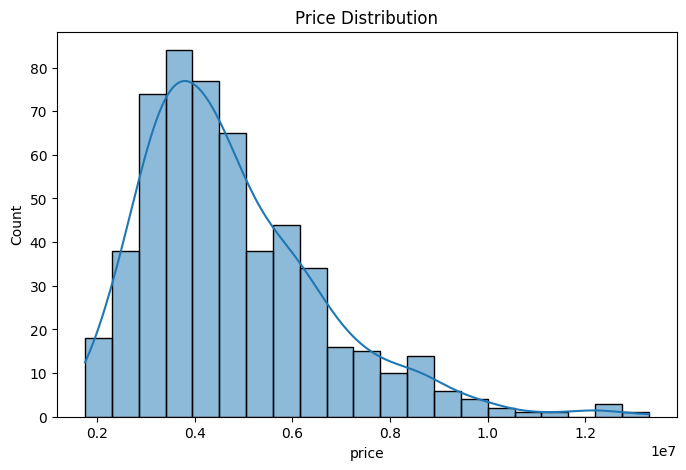

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['price'], kde=True)
plt.title('Price Distribution')
plt.show()

In [9]:
df_encoded = df.copy()

binary_cols = ['mainroad','guestroom','basement',
               'hotwaterheating','airconditioning',
               'prefarea']

for col in binary_cols:
    df_encoded[col] = df_encoded[col].map({'yes':1,'no':0})

df_encoded = pd.get_dummies(df_encoded,
                            columns=['furnishingstatus'],
                            drop_first=True)

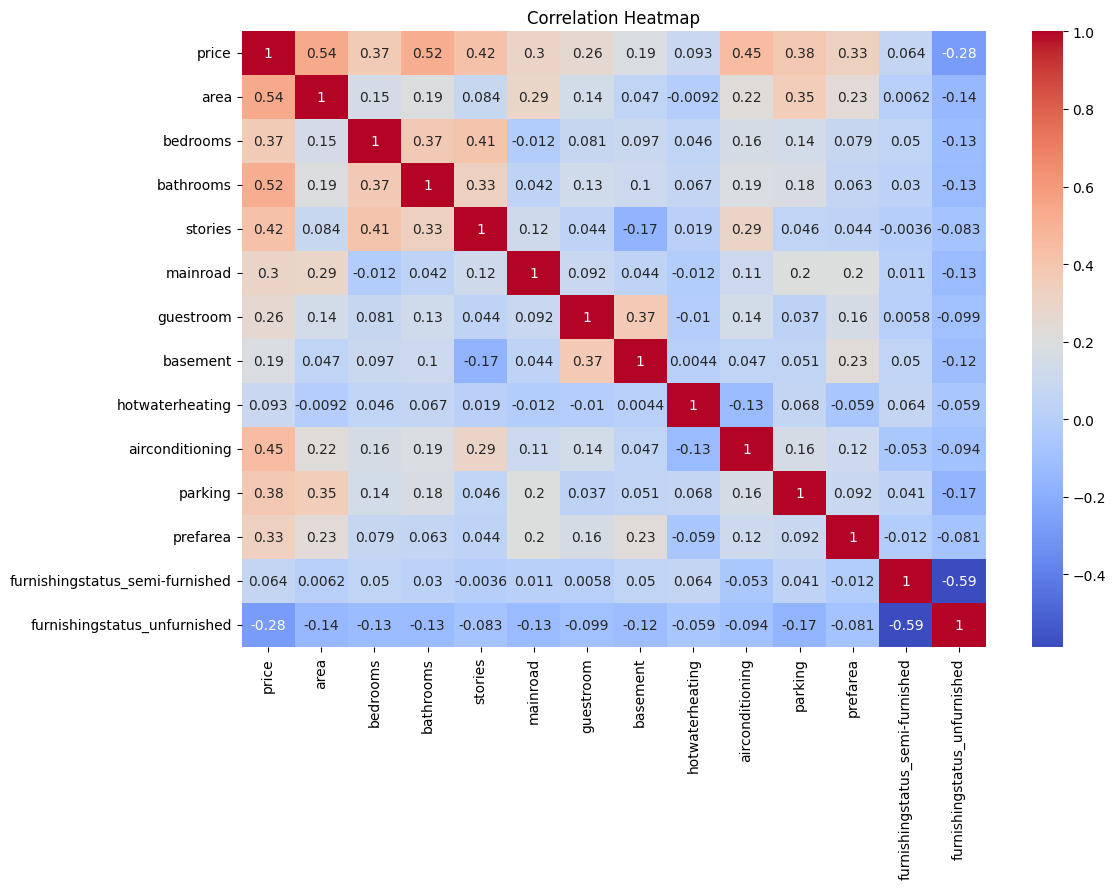

In [10]:
plt.figure(figsize=(12,8))
sns.heatmap(df_encoded.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

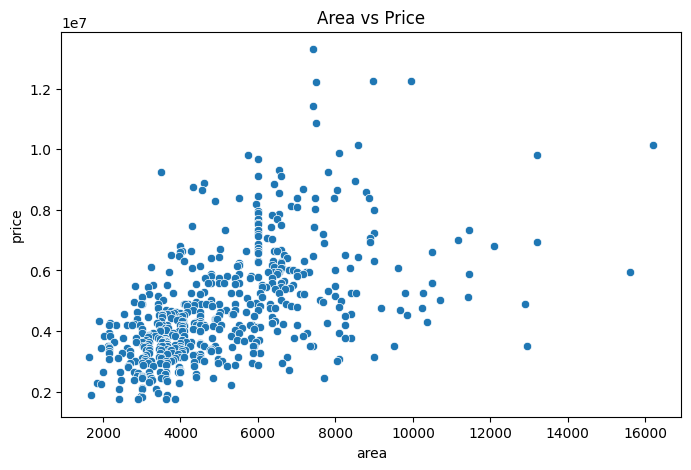

In [11]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x=df['area'],
    y=df['price']
)

plt.title('Area vs Price')
plt.show()

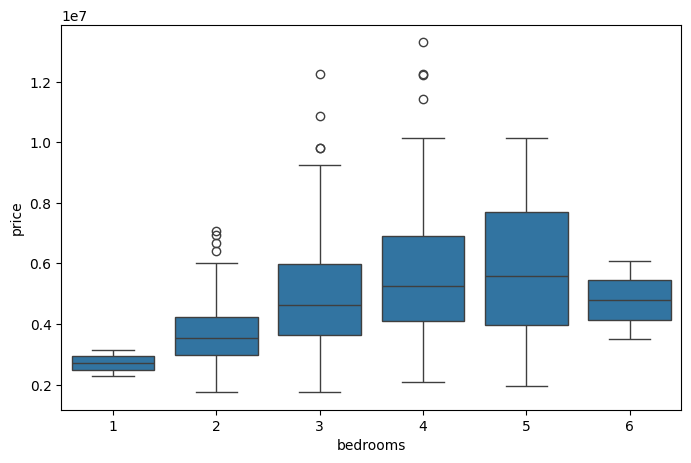

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x=df['bedrooms'],
    y=df['price']
)

plt.show()

<Axes: ylabel='Density'>

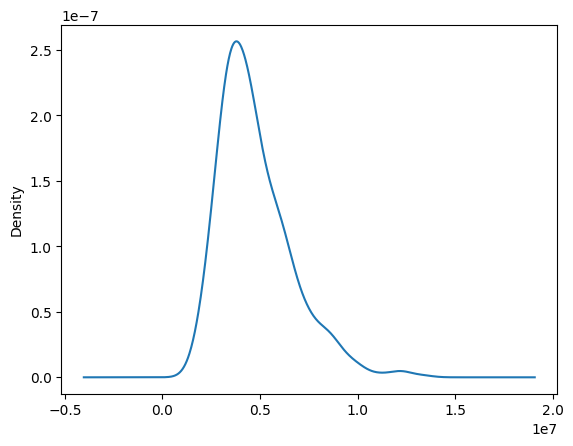

In [18]:
df['price'].plot(kind='kde')

<Axes: ylabel='Density'>

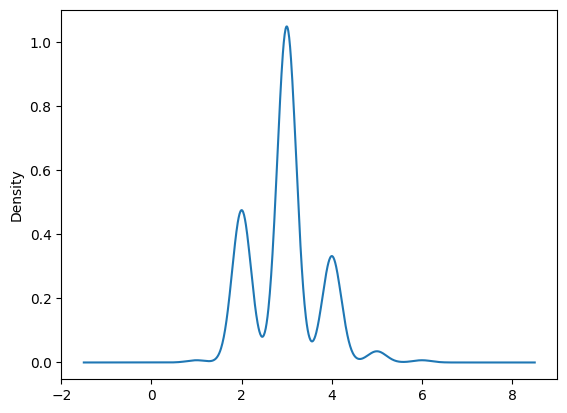

In [19]:
df['bedrooms'].plot(kind='kde')

<Axes: ylabel='count'>

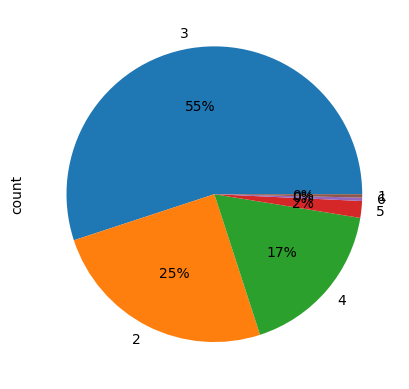

In [21]:
df['bedrooms'].value_counts().plot(kind='pie',autopct='%1.0f%%')

<Axes: xlabel='price', ylabel='bedrooms'>

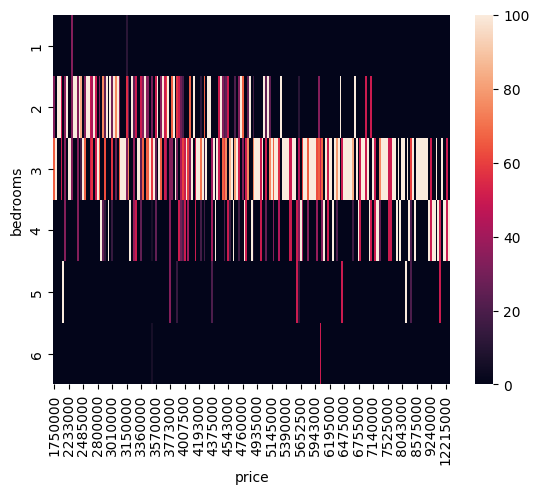

In [27]:
sns.heatmap(pd.crosstab(df['bedrooms'],df['price'],normalize='columns')*100)